# Modeling — Logistic Regression Baseline

Trains a logistic regression classifier to predict rain (>= 1.0 mm precipitation) for Santo Domingo from same-day temperature, humidity, pressure, and wind — the same fields available from Open-Meteo's forecast API at serving time. Uses a chronological train/test split (train on 2015-2022, test on 2023-2024) rather than a random split, since consecutive days are autocorrelated and a random split would leak information between adjacent train/test days — a chronological split better simulates predicting genuinely unseen future weather, matching how the model will be used in production.

In [1]:
import json

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
RAIN_THRESHOLD = 1.0  # mm, WMO wet-day definition (see notebooks/01_eda.ipynb)

df = pd.read_csv("../data/santo_domingo_historical.csv", parse_dates=["date"])
df["is_rain"] = (df["precipitation_sum"] >= RAIN_THRESHOLD).astype(int)
df.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,windspeed_10m_max,precipitation_sum,is_rain
0,2015-01-01,28.4,20.9,24.3,77,1013.4,11.5,0.0,0
1,2015-01-02,28.8,21.6,24.6,76,1014.8,14.9,0.6,0
2,2015-01-03,28.5,21.2,24.2,76,1015.1,19.8,1.2,1
3,2015-01-04,29.3,21.3,24.6,73,1015.4,18.0,0.0,0
4,2015-01-05,29.3,21.2,24.5,71,1015.9,15.5,0.0,0


## Feature engineering

`month` is cyclical (December is adjacent to January), so we encode it as `sin`/`cos` pairs instead of a raw integer, which would falsely imply month 12 is "far" from month 1.

In [2]:
df["month"] = df["date"].dt.month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Same-day atmospheric features available both historically and from the
# Open-Meteo forecast API at serving time. precipitation_sum is deliberately
# excluded — it directly determines the target and would leak the label.
FEATURE_COLUMNS = [
    "temperature_2m_max",
    "temperature_2m_min",
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "surface_pressure_mean",
    "windspeed_10m_max",
    "month_sin",
    "month_cos",
]
TARGET_COLUMN = "is_rain"

df[FEATURE_COLUMNS + [TARGET_COLUMN]].head()

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,windspeed_10m_max,month_sin,month_cos,is_rain
0,28.4,20.9,24.3,77,1013.4,11.5,0.5,0.866025,0
1,28.8,21.6,24.6,76,1014.8,14.9,0.5,0.866025,0
2,28.5,21.2,24.2,76,1015.1,19.8,0.5,0.866025,1
3,29.3,21.3,24.6,73,1015.4,18.0,0.5,0.866025,0
4,29.3,21.2,24.5,71,1015.9,15.5,0.5,0.866025,0


## Chronological train/test split

Train on 2015-2022, test on 2023-2024. This holds out the two most recent years entirely, which is a more honest estimate of production performance than a random split of autocorrelated daily rows.

In [3]:
TEST_START_YEAR = 2023

train_df = df[df["date"].dt.year < TEST_START_YEAR].reset_index(drop=True)
test_df = df[df["date"].dt.year >= TEST_START_YEAR].reset_index(drop=True)

X_train, y_train = train_df[FEATURE_COLUMNS], train_df[TARGET_COLUMN]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df[TARGET_COLUMN]

print(f"Train: {len(X_train)} rows ({train_df['date'].min().date()} to {train_df['date'].max().date()})")
print(f"Test:  {len(X_test)} rows ({test_df['date'].min().date()} to {test_df['date'].max().date()})")
print(f"Train rain rate: {y_train.mean():.1%}  |  Test rain rate: {y_test.mean():.1%}")

Train: 2922 rows (2015-01-01 to 2022-12-31)
Test:  731 rows (2023-01-01 to 2024-12-31)
Train rain rate: 60.4%  |  Test rain rate: 58.3%


## Train logistic regression

Scaling + logistic regression bundled into a single `Pipeline` so the exact same object can be `joblib.dump`ed and used for serving — no separate scaler to keep in sync at inference time.

In [4]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

model.fit(X_train, y_train)
print("Trained.")

Trained.


## Evaluation

We compare against a naive baseline (always predict the majority class from the training set) to confirm the model is actually adding value beyond exploiting class balance.

In [5]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

majority_class = int(y_train.mode()[0])
baseline_pred = np.full_like(y_test, majority_class)

def report(name, y_true, y_pred_):
    print(f"--- {name} ---")
    print(f"accuracy:  {accuracy_score(y_true, y_pred_):.3f}")
    print(f"precision: {precision_score(y_true, y_pred_):.3f}")
    print(f"recall:    {recall_score(y_true, y_pred_):.3f}")
    print(f"f1:        {f1_score(y_true, y_pred_):.3f}")
    print()

report("Naive baseline (always predict majority class)", y_test, baseline_pred)
report("Logistic regression", y_test, y_pred)
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No rain", "Rain"]))

--- Naive baseline (always predict majority class) ---
accuracy:  0.583
precision: 0.583
recall:    1.000
f1:        0.736

--- Logistic regression ---
accuracy:  0.778
precision: 0.793
recall:    0.838
f1:        0.815

ROC-AUC: 0.862

              precision    recall  f1-score   support

     No rain       0.75      0.70      0.72       305
        Rain       0.79      0.84      0.82       426

    accuracy                           0.78       731
   macro avg       0.77      0.77      0.77       731
weighted avg       0.78      0.78      0.78       731



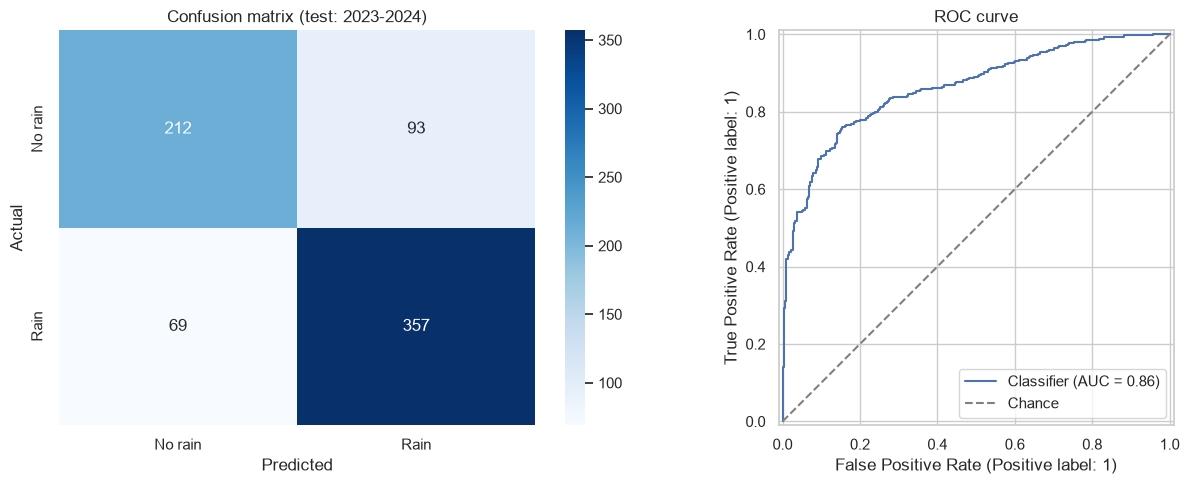

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=["No rain", "Rain"], yticklabels=["No rain", "Rain"],
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion matrix (test: 2023-2024)")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[1].set_title("ROC curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## Coefficients

Since features are standardized, coefficient magnitude reflects relative feature importance directly.

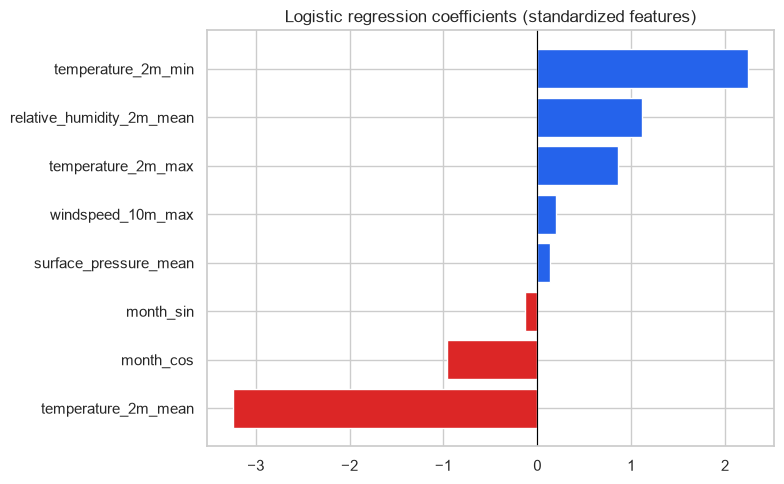

temperature_2m_min           2.247631
relative_humidity_2m_mean    1.119566
temperature_2m_max           0.861124
windspeed_10m_max            0.195353
surface_pressure_mean        0.137574
month_sin                   -0.128655
month_cos                   -0.960593
temperature_2m_mean         -3.241918
dtype: float64

In [7]:
coefs = pd.Series(
    model.named_steps["classifier"].coef_[0], index=FEATURE_COLUMNS
).sort_values()

plt.figure(figsize=(8, 5))
colors = ["#dc2626" if c < 0 else "#2563eb" for c in coefs]
plt.barh(coefs.index, coefs.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic regression coefficients (standardized features)")
plt.tight_layout()
plt.show()

coefs.sort_values(ascending=False)

**Caveat on the temperature coefficients:** `temperature_2m_max`, `_min`, and `_mean` are highly collinear (mean is roughly `(max + min) / 2`), which is why their individual coefficients are large and partly offsetting (e.g. `temperature_2m_mean` at -3.24 vs. `temperature_2m_min` at +2.25). This is a standard multicollinearity artifact — it doesn't hurt the model's predictive performance (which is measured on held-out accuracy/ROC-AUC above), but the three temperature coefficients shouldn't be read individually as "importance." Humidity and pressure, which aren't collinear with anything else here, are more directly interpretable: humidity pushes rain probability up, pressure pushes it down — both physically sensible.

## Refit on full history and save for serving

The held-out 2023-2024 test set already gave us an honest performance estimate above. For the artifact we actually ship, we refit the same pipeline on the full 2015-2024 history so the production model benefits from the most recent data too — standard practice once evaluation is done.

We save two artifacts:
- `model/model.pkl` — the fitted `Pipeline` (scaler + logistic regression), so the API can call `.predict_proba()` directly on raw feature values.
- `model/feature_config.json` — the exact feature column order/names and the rain threshold, so the FastAPI backend builds feature vectors identically to training (no hardcoded duplication, no drift risk).

In [8]:
from pathlib import Path

MODEL_DIR = Path("../model")
MODEL_DIR.mkdir(exist_ok=True)

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])
final_model.fit(df[FEATURE_COLUMNS], df[TARGET_COLUMN])

joblib.dump(final_model, MODEL_DIR / "model.pkl")

feature_config = {
    "feature_columns": FEATURE_COLUMNS,
    "rain_threshold_mm": RAIN_THRESHOLD,
    "trained_on": {
        "start_date": str(df["date"].min().date()),
        "end_date": str(df["date"].max().date()),
        "n_rows": len(df),
    },
    "held_out_test_metrics": {
        "accuracy": round(accuracy_score(y_test, y_pred), 3),
        "precision": round(precision_score(y_test, y_pred), 3),
        "recall": round(recall_score(y_test, y_pred), 3),
        "f1": round(f1_score(y_test, y_pred), 3),
        "roc_auc": round(roc_auc_score(y_test, y_proba), 3),
        "test_period": f"{TEST_START_YEAR}-01-01 to {df['date'].max().date()}",
    },
}

with open(MODEL_DIR / "feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=2)

print(f"Saved {MODEL_DIR / 'model.pkl'}")
print(f"Saved {MODEL_DIR / 'feature_config.json'}")
print(json.dumps(feature_config, indent=2))

Saved ..\model\model.pkl
Saved ..\model\feature_config.json
{
  "feature_columns": [
    "temperature_2m_max",
    "temperature_2m_min",
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "surface_pressure_mean",
    "windspeed_10m_max",
    "month_sin",
    "month_cos"
  ],
  "rain_threshold_mm": 1.0,
  "trained_on": {
    "start_date": "2015-01-01",
    "end_date": "2024-12-31",
    "n_rows": 3653
  },
  "held_out_test_metrics": {
    "accuracy": 0.778,
    "precision": 0.793,
    "recall": 0.838,
    "f1": 0.815,
    "roc_auc": 0.862,
    "test_period": "2023-01-01 to 2024-12-31"
  }
}
